In this notebook we do hyperparameter tuning on three linear models, along with their regularized counterpart lasso + ridge. As well, we train an xgboost model. The models are:
- Linear model with no feature selection.
- Linear model with log on the bunching events.
- Linear model where we take logarithm on the target dt_short and bunching events.

Our training is done by 5 fold cross validation using a time series split.

In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import os
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import r2_score
from sklearn.metrics import root_mean_squared_error as rmse
import xgboost as xgb

In [2]:
#by_day_data = '../data/schedule_data/processed_data/by_day_short_and_long/'

#by_day_data_list = [x for x in os.listdir(by_day_data) if 'train.csv' in x]

by_day_data = "../../data/schedule_data/train_test_split_data/by_day_short_and_long/"
by_day_data_list = [x for x in os.listdir(by_day_data) if 'train.csv' in x]
dtypes = pd.read_csv(f'{os.path.join(by_day_data,by_day_data_list[0])}', nrows=1).iloc[0].to_dict()



def to_csv(df, path):
    # Prepend dtypes to the top of df (from https://stackoverflow.com/a/43408736/7607701)
    df.loc[-1] = df.dtypes
    df.index = df.index + 1
    df.sort_index(inplace=True)
    # Then save it to a csv
    df.to_csv(path, index=False)

def read_csv(path):
    # Read types first line of csv
    dtypes = {key:value for (key,value) in pd.read_csv(path,
              nrows=1).iloc[0].to_dict().items() if 'date' not in value}

    parse_dates = [key for (key,value) in pd.read_csv(path,
                   nrows=1).iloc[0].to_dict().items() if 'date' in value]
    # Read the rest of the lines with the types from above
    return pd.read_csv(path, dtype=dtypes, parse_dates=parse_dates, skiprows=[1])

In [3]:
daily_df = read_csv(by_day_data+by_day_data_list[0])
daily_df = daily_df[daily_df['date'].between(pd.Timestamp('2024-07-30'), pd.Timestamp('2025-09-01'), inclusive='left')]

daily_df = daily_df.rename(columns={'delay time (5,19]':'dt_short', 'delay time (19,120]':'dt_long', 'EB/WB':'dir'})

In [4]:
daily_df.head()

,date,dir,stop,bunch,gap,dt_short,dt_long,No. of Veh,Run time (min),Term time (min),Avg. spd (km/h),RT dist (km),Interruption
0,2024-07-30,E,Indian Rd,0,0,0.0,0.0,16.4,153.4,10.6,11.92,30.13,0
1,2024-07-30,E,Coxwell Ave at Gerrard St East,0,0,0.0,0.0,16.4,153.4,10.6,11.92,30.13,0
2,2024-07-30,E,Grace St,0,0,0.0,0.0,16.4,153.4,10.6,11.92,30.13,0
3,2024-07-30,W,Woodbine Ave,0,0,0.0,0.0,16.4,153.4,10.6,11.92,30.13,0
4,2024-07-30,E,De Grassi St,0,0,0.0,0.0,16.4,153.4,10.6,11.92,30.13,0


In [5]:
# I want to add daily weather data.
weather=pd.read_csv('../../raw_data/Weatherstats_data/weatherstats_toronto_daily.csv')
#drop columns that consist exclusively of NaNs
weather.dropna(axis=1, how='all', inplace=True)
#Convert date from string to datetime type
weather.date = weather.date.apply(pd.Timestamp)

#fill remainder of the NaNs with '0'
weather.fillna(0, inplace=True)

columns = weather.columns
#the following columns have a deterministic relationship with the temperature so we are dropping them
columns = [x for x in columns if 'degdays' not in x]

# Choosing avg stats vs max/min stats
columns = [x for x in columns if 'max' not in x and 'min' not in x]
# Removing 'hourly data'
columns = [x for x in columns if 'hourly' not in x]
# Picking one time format
columns = [x for x in columns if 'sunrise_f' != x and 'sunset_f' != x]
columns = [x for x in columns if 'unixtime' not in x]
# Picking station pressure vs sea pressure
columns = [x for x in columns if 'avg_pressure_sea' != x]


weather['sunrise_hhmm'] = weather['sunrise_hhmm'].apply(pd.Timedelta)
weather['sunset_hhmm'] = weather['sunset_hhmm'].apply(pd.Timedelta)

weather = weather[columns]

In [6]:
first_date = daily_df['date'].min()
last_date = daily_df['date'].max()
weather = weather[weather['date'].between(first_date,last_date)]
weather.head()

,date,avg_temperature,avg_relative_humidity,avg_dew_point,avg_wind_speed,wind_gust_dir_10s,avg_pressure_station,avg_visibility,avg_health_index,precipitation,rain,snow,snow_on_ground,sunrise_hhmm,sunset_hhmm,daylight,avg_cloud_cover_8
174,2025-08-31,16.39,57.5,9.1,8.5,0.0,100.36,24100,2.0,0.0,0.0,0.0,0.0,0 days 06:40:00,0 days 19:55:00,13.25,2.0
175,2025-08-30,15.00,58.5,7.5,13.0,31.0,99.96,24100,2.0,0.0,0.0,0.0,0.0,0 days 06:39:00,0 days 19:57:00,13.30,3.5
176,2025-08-29,13.55,64.5,6.0,19.5,31.0,99.73,24100,1.7,0.0,0.0,0.0,0.0,0 days 06:38:00,0 days 19:59:00,13.35,4.0
177,2025-08-28,14.95,73.5,11.8,17.5,32.0,99.53,18500,2.2,5.4,5.4,0.0,0.0,0 days 06:36:00,0 days 20:00:00,13.40,4.0
178,2025-08-27,17.00,58.0,6.7,19.5,26.0,99.86,24100,2.1,0.0,0.0,0.0,0.0,0 days 06:35:00,0 days 20:02:00,13.45,3.0


In [7]:
daily_df = pd.merge(daily_df, weather, on='date')

In [8]:
daily_df.head()

,date,dir,stop,bunch,gap,dt_short,dt_long,No. of Veh,Run time (min),Term time (min),...,avg_visibility,avg_health_index,precipitation,rain,snow,snow_on_ground,sunrise_hhmm,sunset_hhmm,daylight,avg_cloud_cover_8
0,2024-07-30,E,Indian Rd,0,0,0.0,0.0,16.4,153.4,10.6,...,20100,2.8,7.4,7.4,0.0,0.0,0 days 06:05:00,0 days 20:42:00,14.62,5.0
1,2024-07-30,E,Coxwell Ave at Gerrard St East,0,0,0.0,0.0,16.4,153.4,10.6,...,20100,2.8,7.4,7.4,0.0,0.0,0 days 06:05:00,0 days 20:42:00,14.62,5.0
2,2024-07-30,E,Grace St,0,0,0.0,0.0,16.4,153.4,10.6,...,20100,2.8,7.4,7.4,0.0,0.0,0 days 06:05:00,0 days 20:42:00,14.62,5.0
3,2024-07-30,W,Woodbine Ave,0,0,0.0,0.0,16.4,153.4,10.6,...,20100,2.8,7.4,7.4,0.0,0.0,0 days 06:05:00,0 days 20:42:00,14.62,5.0
4,2024-07-30,E,De Grassi St,0,0,0.0,0.0,16.4,153.4,10.6,...,20100,2.8,7.4,7.4,0.0,0.0,0 days 06:05:00,0 days 20:42:00,14.62,5.0


In [9]:
# Fill na values with 0
daily_df.fillna(0, inplace=True)

# Add log of features
daily_df['log_bunch'] = np.log1p(daily_df['bunch'])
daily_df['log_dt_short'] = np.log1p(daily_df['dt_short'])
daily_df['log_dt_long'] = np.log1p(daily_df['dt_long'])

# Turn direction and stop into categories
daily_df['stop'] = daily_df['stop'].astype('category')
daily_df['dir'] = daily_df['dir'].astype('category')

daily_df = daily_df.sort_values("date").reset_index(drop=True)

We start with some exploratory data analysis. Below is a correlation heatmap of the features. Note that bunch and gap events are highly correlated with dt_short. The features are less correlated with dt_long, but there is some moderate correlation between dt_long and the amount of snow on the ground.

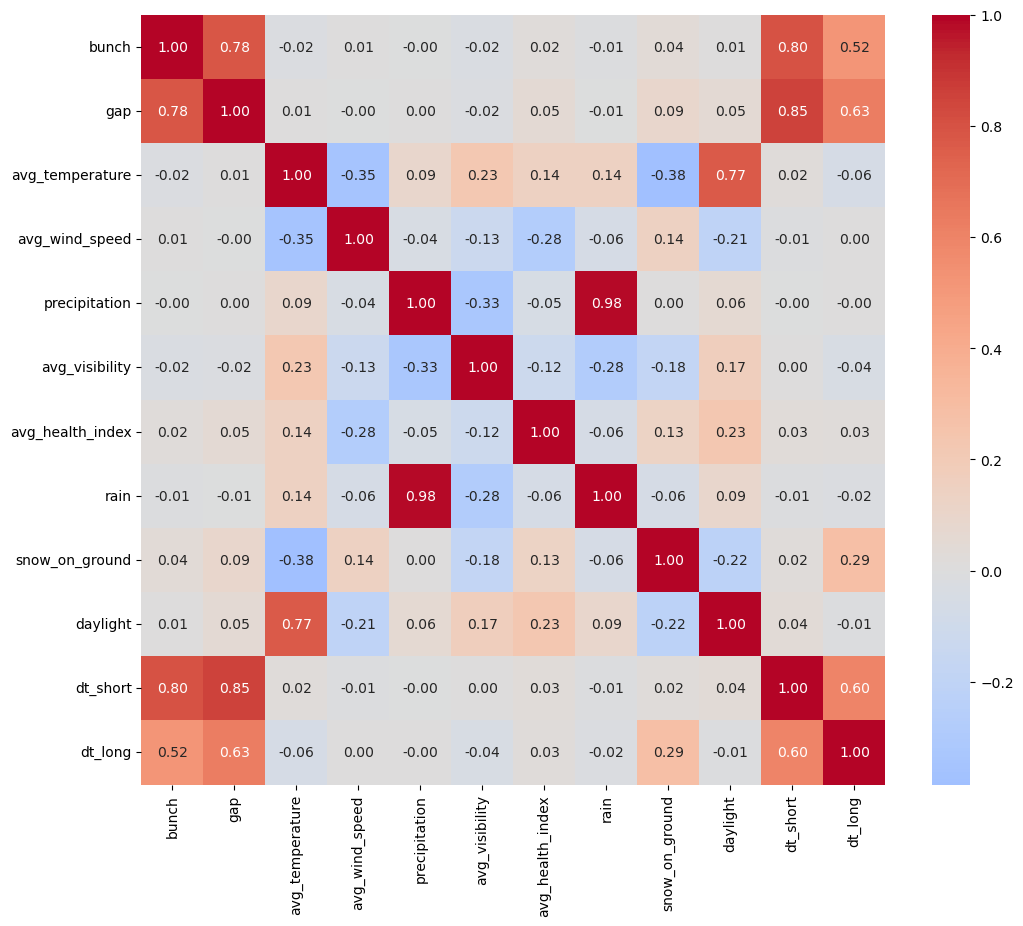

In [10]:
features = ['bunch', 'gap','avg_temperature', 'avg_wind_speed', 'precipitation', 'avg_visibility', 'avg_health_index', 'rain', 'snow_on_ground', 'daylight']
targets = [x for x in daily_df.columns if 'dt_' in x and 'log' not in x]

corr_matrix = daily_df[features+targets].corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f');

A plot of dt_long and snow on ground makes this feature clear.

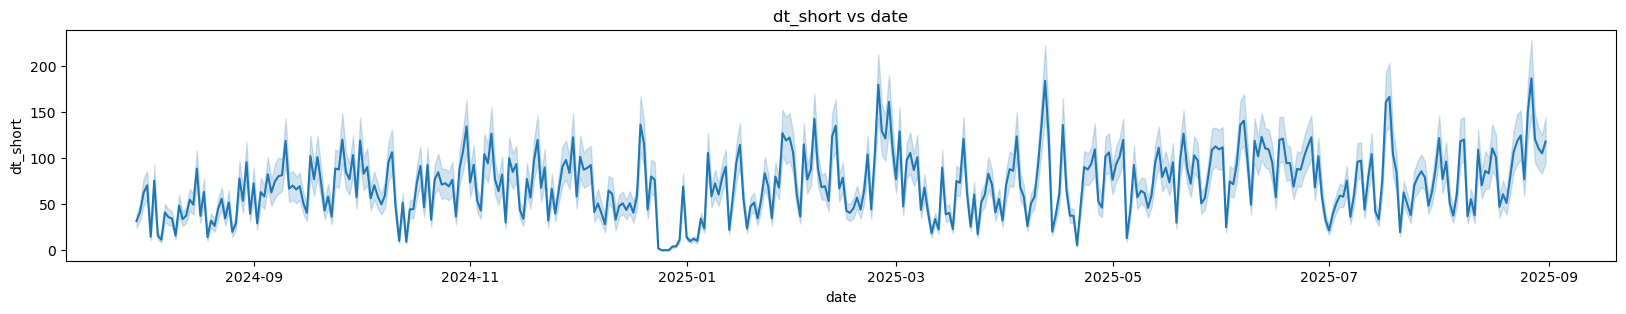

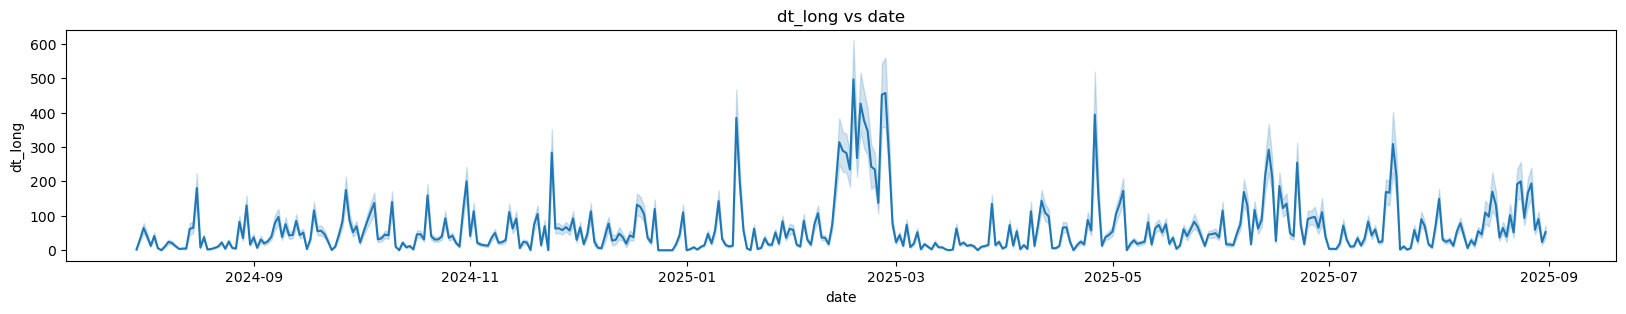

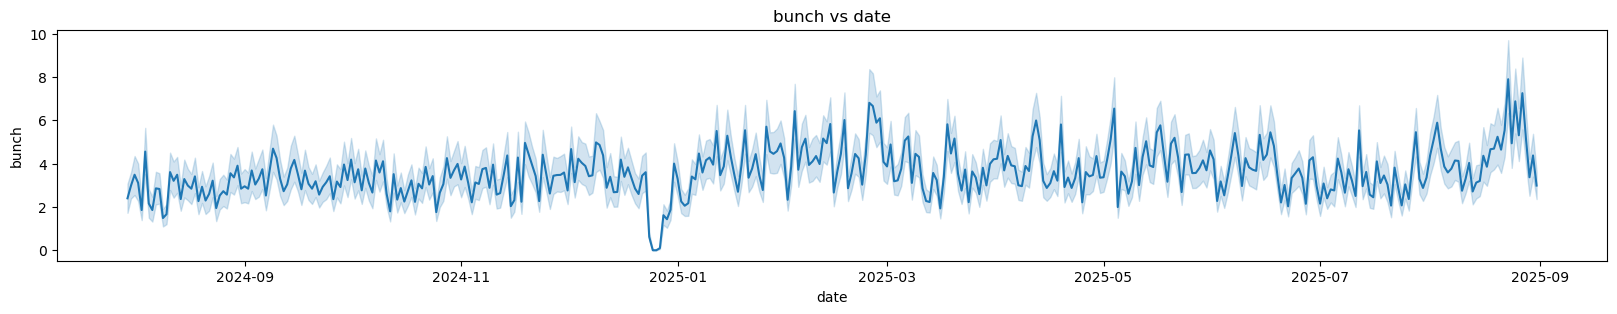

In [11]:
for dt in ['dt_short', 'dt_long']:
    plt.figure(figsize=(20, 3))
    sns.lineplot(data=daily_df, x='date', y=dt)
    plt.title(f'{dt} vs date')
    plt.show()

plt.figure(figsize=(20, 3))
sns.lineplot(data=daily_df, x='date', y='bunch')
plt.title('bunch vs date')
plt.show()

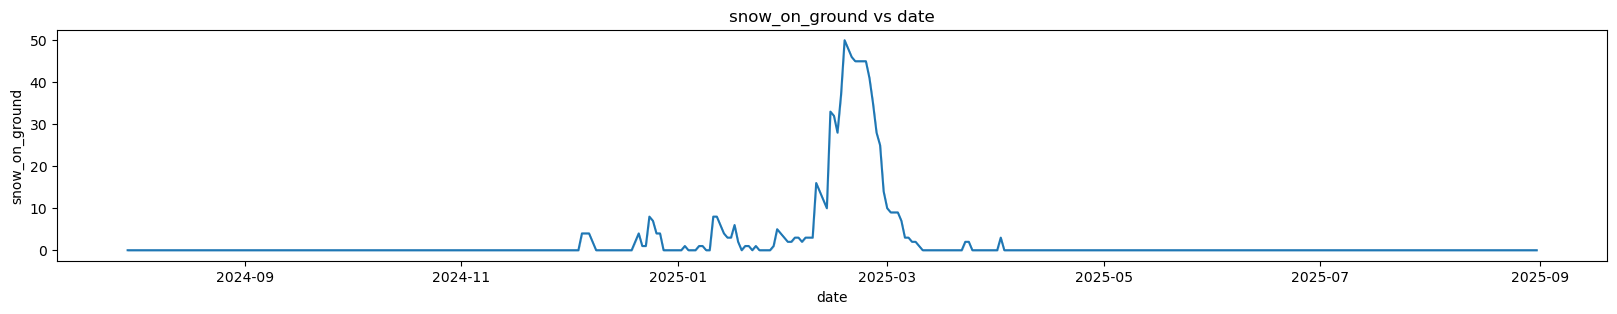

In [12]:
plt.figure(figsize=(20,3))
sns.lineplot(data=daily_df, x='date', y='snow_on_ground')
plt.title('snow_on_ground vs date')
plt.show()

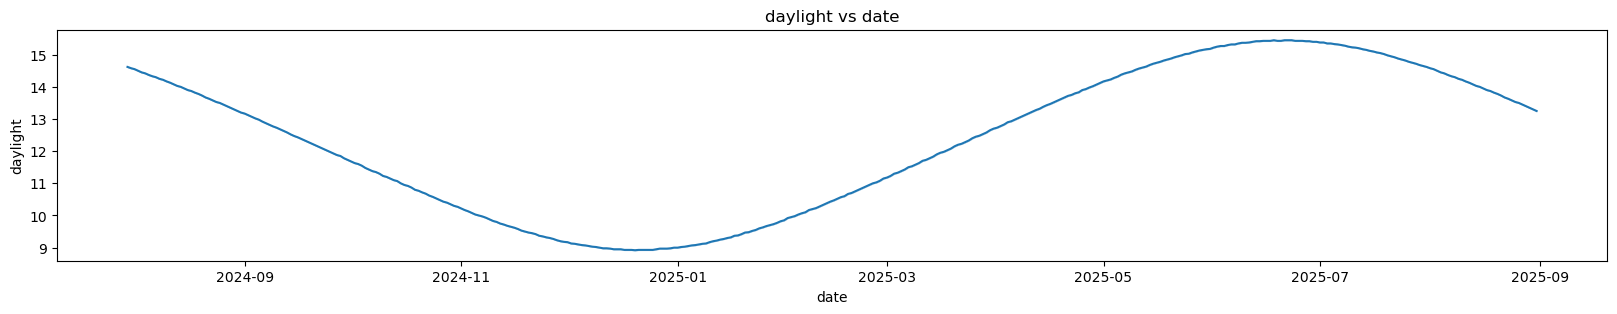

In [13]:
plt.figure(figsize=(20,3))
sns.lineplot(data=daily_df, x='date', y='daylight')
plt.title('daylight vs date')
plt.show()

Lets compare bunch and dt_short with dt_long in a few different ways.

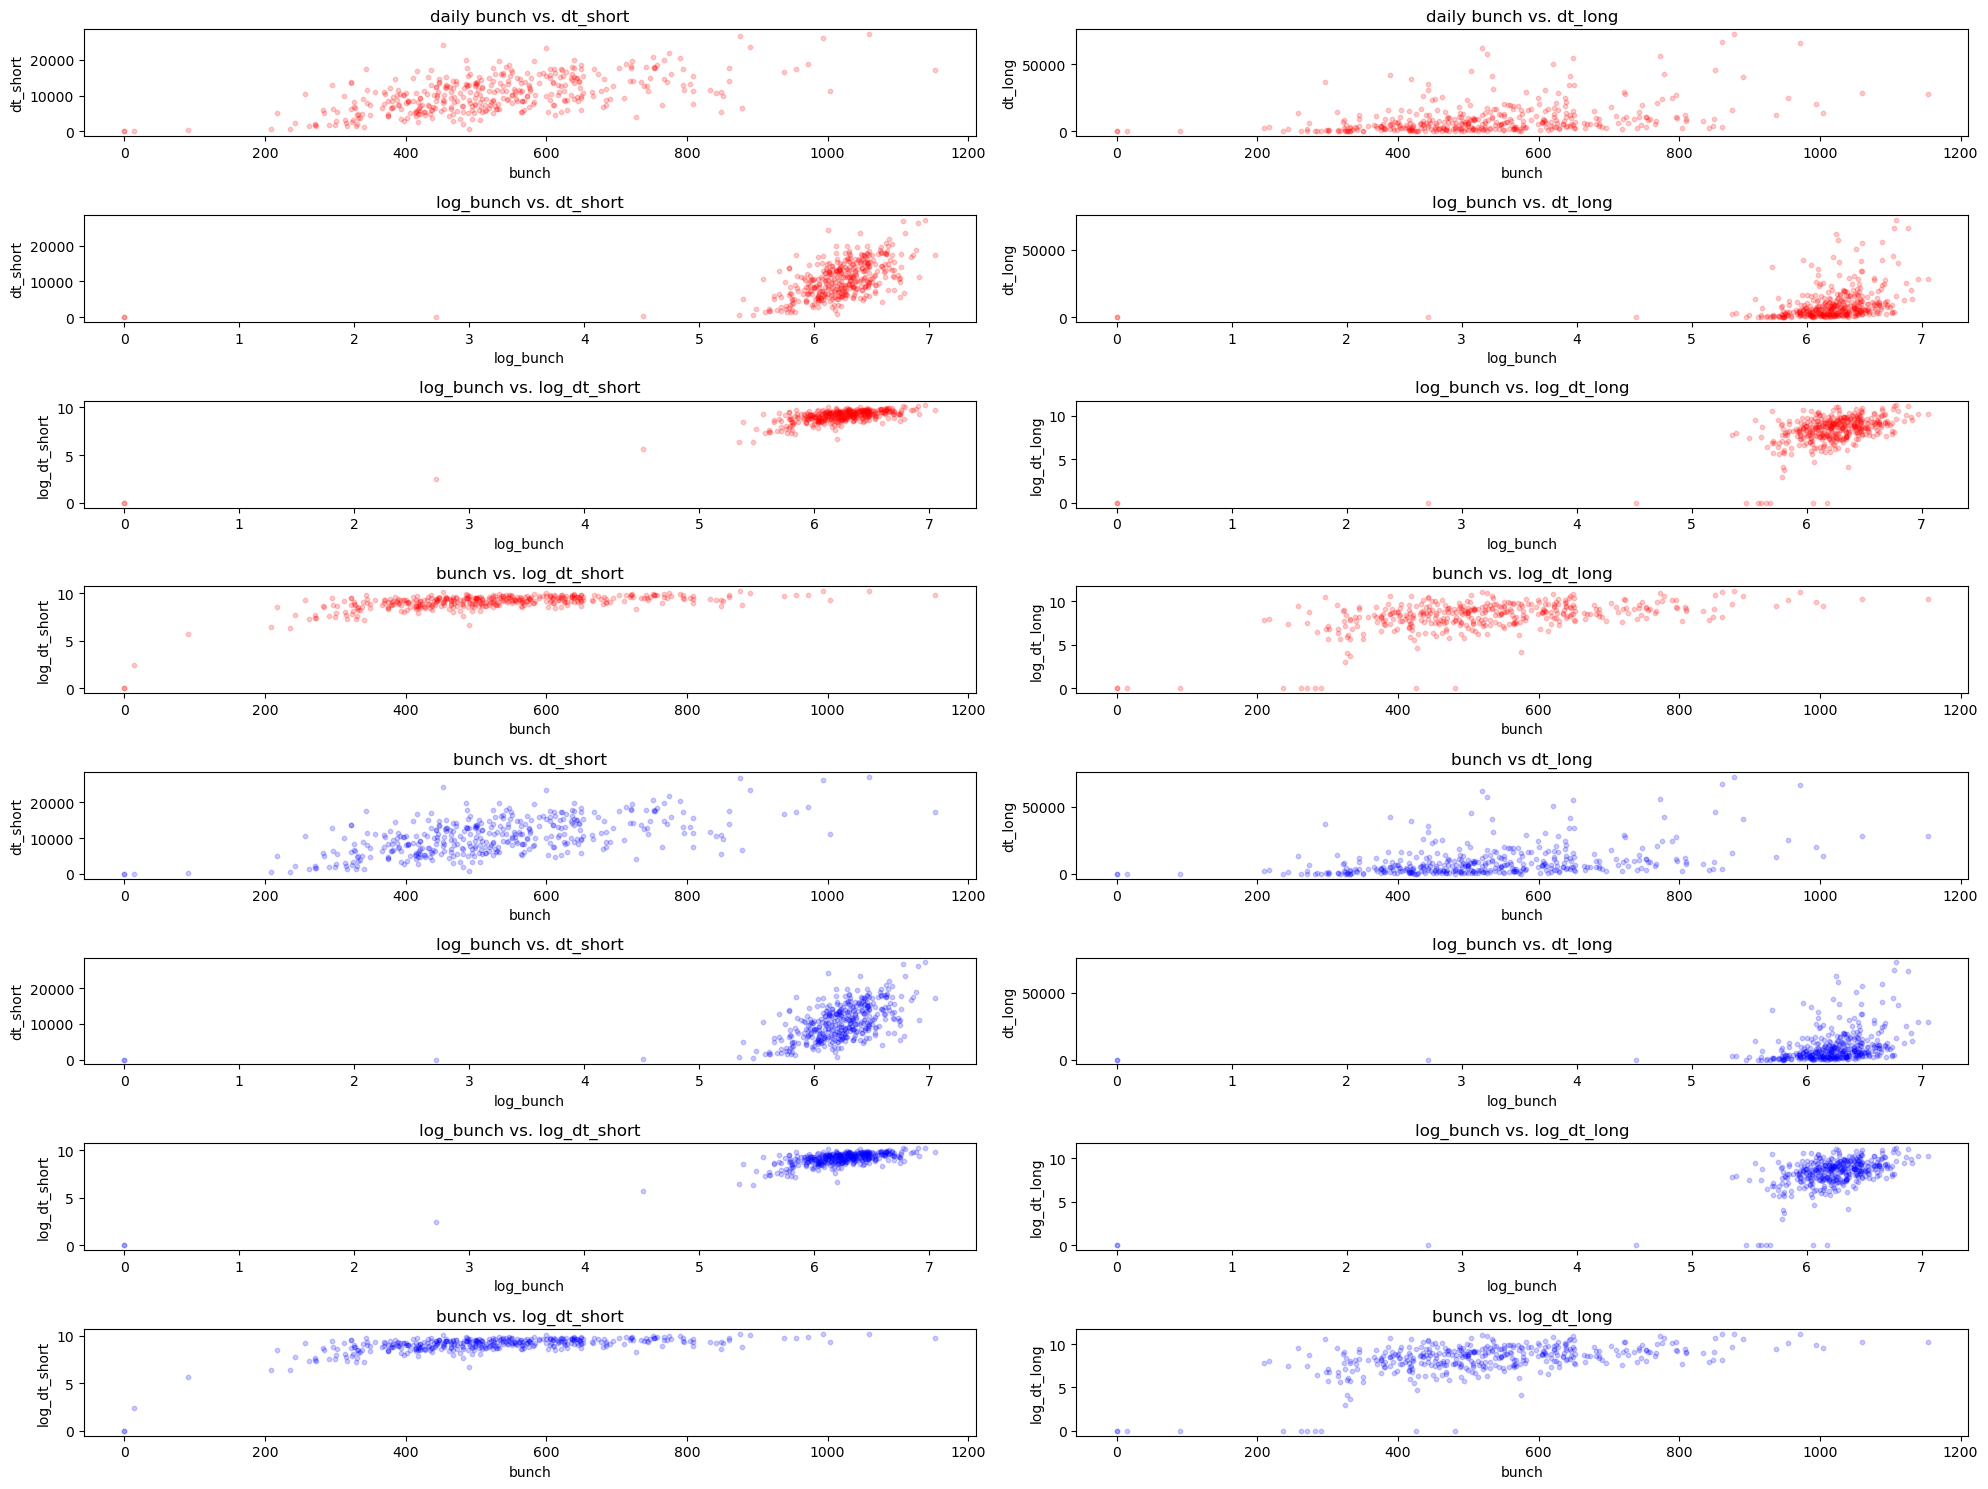

In [16]:
#Calculate totals (sum on minutes delayed and sum of number of occurrences) for each day
stats_df = (
                daily_df
                .groupby('date')[['bunch','dt_short','dt_long']]
                .sum()
                .reset_index()
)

#We will also look at what happens when we take a log transform of these

# Create transformed variables

stats_df['log_bunch'] = np.log1p(stats_df['bunch'])
stats_df['log_dt_short'] = np.log1p(stats_df['dt_short'])
stats_df['log_dt_long'] = np.log1p(stats_df['dt_long'])



stats_df['log_bunch'] = np.log1p(stats_df['bunch'])
stats_df['log_dt_short'] = np.log1p(stats_df['dt_short'])
stats_df['log_dt_long'] = np.log1p(stats_df['dt_long'])

fig, axes = plt.subplots(8, 2, figsize=(20,15))



# -----------------------------
# Daily totals
# -----------------------------

# gap vs delay
axes[0,0].scatter(
                stats_df['bunch'],
                stats_df['dt_short'],
                alpha=0.2,
                s=10,
                color='red'
)
axes[0,0].set_xlabel("bunch")
axes[0,0].set_ylabel("dt_short")
axes[0,0].set_title("daily bunch vs. dt_short")

# bunch vs delay
axes[0,1].scatter(
                stats_df['bunch'],
                stats_df['dt_long'],
                alpha=0.2,
                s=10,
                color='red'
)
axes[0,1].set_xlabel("bunch")
axes[0,1].set_ylabel("dt_long")
axes[0,1].set_title("daily bunch vs. dt_long")

# -----------------------------
# Log transforms of bunches
# -----------------------------

# log bunch vs short delay
axes[1,0].scatter(
                stats_df['log_bunch'],
                stats_df['dt_short'],
                alpha=0.2,
                s=10,
                color='red'
)
axes[1,0].set_xlabel("log_bunch")
axes[1,0].set_ylabel("dt_short")
axes[1,0].set_title("log_bunch vs. dt_short")

# log bunch vs long delay

axes[1,1].scatter(
                stats_df['log_bunch'],
                stats_df['dt_long'],
                alpha=0.2,
                s=10,
                color='red'
)
axes[1,1].set_xlabel("log_bunch")
axes[1,1].set_ylabel("dt_long")
axes[1,1].set_title("log_bunch vs. dt_long")



# -----------------------------
# Log transforms of delays and bunches
# -----------------------------

# log bunch vs log short delay

axes[2,0].scatter(
                stats_df['log_bunch'],
                stats_df['log_dt_short'],
                alpha=0.2,
                s=10,
                color='red'
)
axes[2,0].set_xlabel("log_bunch")
axes[2,0].set_ylabel("log_dt_short")
axes[2,0].set_title("log_bunch vs. log_dt_short")

# log bunch vs log long delay

axes[2,1].scatter(
                stats_df['log_bunch'],
                stats_df['log_dt_long'],
                alpha=0.2,
                s=10,
                color='red'
)
axes[2,1].set_xlabel("log_bunch")
axes[2,1].set_ylabel("log_dt_long")
axes[2,1].set_title("log_bunch vs. log_dt_long")

# -----------------------------
# Log transforms of delays
# -----------------------------

# bunch vs log short delay

axes[3,0].scatter(
                stats_df['bunch'],
                stats_df['log_dt_short'],
                alpha=0.2,
                s=10,
                color='red'
)
axes[3,0].set_xlabel("bunch")
axes[3,0].set_ylabel("log_dt_short")
axes[3,0].set_title("bunch vs. log_dt_short")

#     bunch vs log long delay

axes[3,1].scatter(
                stats_df['bunch'],
                stats_df['log_dt_long'],
                alpha=0.2,
                s=10,
                color='red'
)
axes[3,1].set_xlabel("bunch")
axes[3,1].set_ylabel("log_dt_long")
axes[3,1].set_title("bunch vs. log_dt_long")

# -----------------------------
# Individual observations
# -----------------------------



axes[4,0].scatter(
                stats_df['bunch'],
                stats_df['dt_short'],
                alpha=0.2,
                s=10,
                color='blue'
)
axes[4,0].set_xlabel("bunch")
axes[4,0].set_ylabel("dt_short")
axes[4,0].set_title("bunch vs. dt_short")

# bunch vs delay
axes[4,1].scatter(
                stats_df['bunch'],
                stats_df['dt_long'],
                alpha=0.2,
                s=10,
                color='blue'
)
axes[4,1].set_xlabel("bunch")
axes[4,1].set_ylabel("dt_long")
axes[4,1].set_title("bunch vs dt_long")



# -----------------------------
# Log transforms of bunches
# -----------------------------

# log bunch vs short delay
axes[5,0].scatter(
                stats_df['log_bunch'],
                stats_df['dt_short'],
                alpha=0.2,
                s=10,
                color='blue'
)
axes[5,0].set_xlabel("log_bunch")
axes[5,0].set_ylabel("dt_short")
axes[5,0].set_title("log_bunch vs. dt_short")

# log bunch vs long delay

axes[5,1].scatter(
                stats_df['log_bunch'],
                stats_df['dt_long'],
                alpha=0.2,
                s=10,
                color='blue'
)
axes[5,1].set_xlabel("log_bunch")
axes[5,1].set_ylabel("dt_long")
axes[5,1].set_title("log_bunch vs. dt_long")



# -----------------------------
# Log transforms of delays and bunches
# -----------------------------

# log bunch vs log short delay

axes[6,0].scatter(
                stats_df['log_bunch'],
                stats_df['log_dt_short'],
                alpha=0.2,
                s=10,
                color='blue'
)
axes[6,0].set_xlabel("log_bunch")
axes[6,0].set_ylabel("log_dt_short")
axes[6,0].set_title("log_bunch vs. log_dt_short")

# log bunch vs log long delay

axes[6,1].scatter(
                stats_df['log_bunch'],
                stats_df['log_dt_long'],
                alpha=0.2,
                s=10,
                color='blue'
)
axes[6,1].set_xlabel("log_bunch")
axes[6,1].set_ylabel("log_dt_long")
axes[6,1].set_title("log_bunch vs. log_dt_long")

# -----------------------------
# Log transforms of delays
# -----------------------------

# bunch vs log short delay

axes[7,0].scatter(
                stats_df['bunch'],
                stats_df['log_dt_short'],
                alpha=0.2,
                s=10,
                color='blue'
)
axes[7,0].set_xlabel("bunch")
axes[7,0].set_ylabel("log_dt_short")
axes[7,0].set_title("bunch vs. log_dt_short")

#     bunch vs log long delay

axes[7,1].scatter(
                stats_df['bunch'],
                stats_df['log_dt_long'],
                alpha=0.2,
                s=10,
    color='blue'
)
axes[7,1].set_xlabel("bunch")
axes[7,1].set_ylabel("log_dt_long")
axes[7,1].set_title("bunch vs. log_dt_long")
plt.tight_layout()
plt.show()

Note that there appears to be a linear relationship between bunch events and dt_short. The rest of this document is focused on hyperparameter tuning.

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, root_mean_squared_error
import xgboost as xgb

# -----------------------------
# Model configurations
# -----------------------------
models = {
    "raw_linear": {
        "estimator": LinearRegression(),
        "target": {"dt_short": "dt_short"},
        "cat_features": ["dir", "stop"],
        "num_features": [
            "bunch", "avg_temperature", "avg_wind_speed", "avg_visibility",
            "avg_health_index", "rain", "snow_on_ground", "daylight"
        ],
        "scale_numeric": True
    },

  #  "log_targets_linear": {
  #      "estimator": LinearRegression(),
  #      "target": {"dt_short": "log_dt_short"},
  #      "cat_features": ["dir", "stop"],
  #      "num_features": [
  #          "bunch", "avg_temperature", "avg_wind_speed", "avg_visibility",
  #          "avg_health_index", "rain", "snow_on_ground", "daylight"
  #      ],
  #      "scale_numeric": True
  #  },

    "log_log_linear": {
        "estimator": LinearRegression(),
        "target": {"dt_short": "log_dt_short"},
        "cat_features": ["dir", "stop"],
        "num_features": [
            "log_bunch", "avg_temperature", "avg_wind_speed", "avg_visibility",
            "avg_health_index", "rain", "snow_on_ground", "daylight"
        ],
        "scale_numeric": True
    },

    "log_bunch_linear": {
        "estimator": LinearRegression(),
        "target": {"dt_short": "dt_short"},
        "cat_features": ["dir", "stop"],
        "num_features": [
            "log_bunch", "avg_temperature", "avg_wind_speed", "avg_visibility",
            "avg_health_index", "rain", "snow_on_ground", "daylight"
        ],
        "scale_numeric": True
    },

    # XGBoost added into same framework
    "xgboost": {
        "estimator": xgb.XGBRegressor(
            objective="reg:squarederror",
            n_estimators=100,
            learning_rate=0.1,
            subsample=0.7,
            max_depth=6,
            reg_alpha=4,
            reg_lambda=5,
            random_state=37
        ),
        "target": {"dt_short": "dt_short"},
        "cat_features": ["dir", "stop"],
        "num_features": [
            "bunch", "avg_temperature", "avg_wind_speed", "avg_visibility",
            "avg_health_index", "rain", "snow_on_ground", "daylight"
        ],
        "scale_numeric": False
    },
}

Below are the results for linear models with no regularization and XGBoost. The residual plots demonstrate that no feature selection and log bunching are reasonable linear models, alongside xgboost. Note that there are no values of the residual below the line $y=-x$, since dt_short cannot be negative.

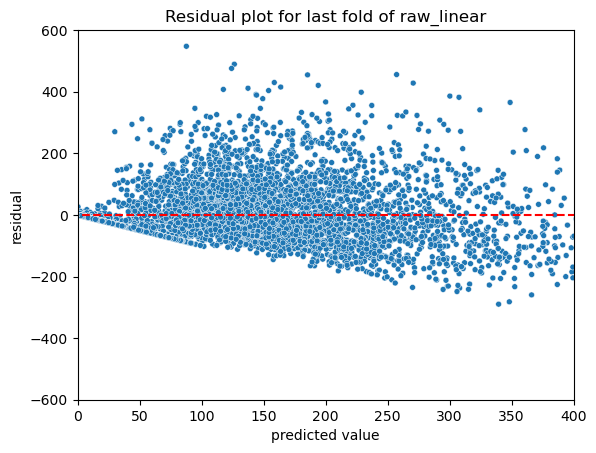

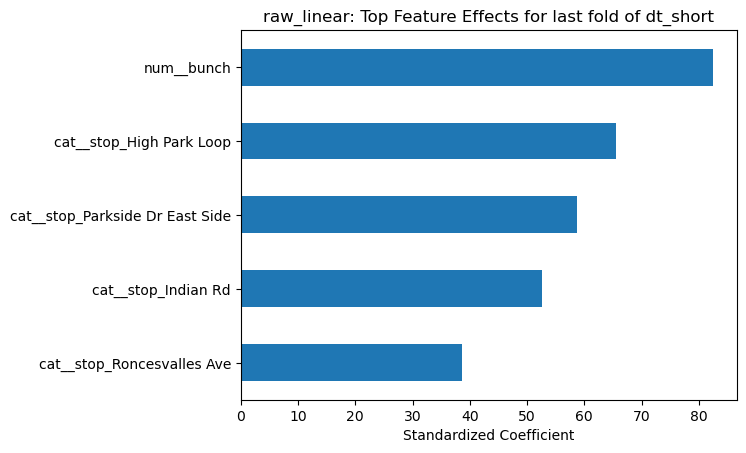

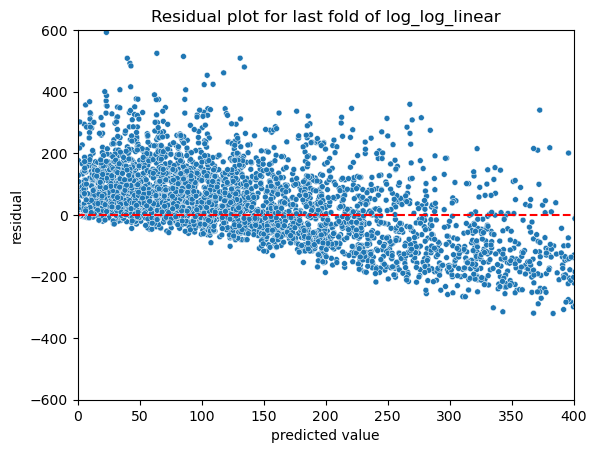

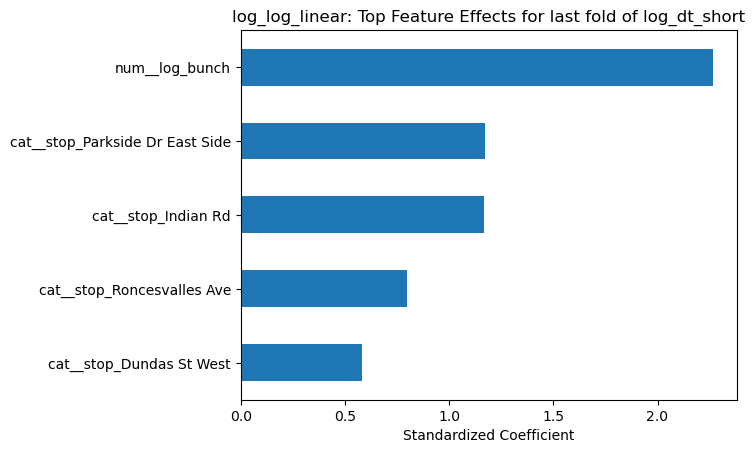

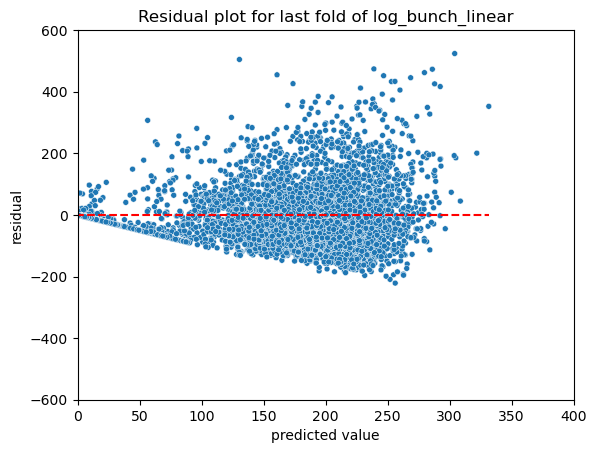

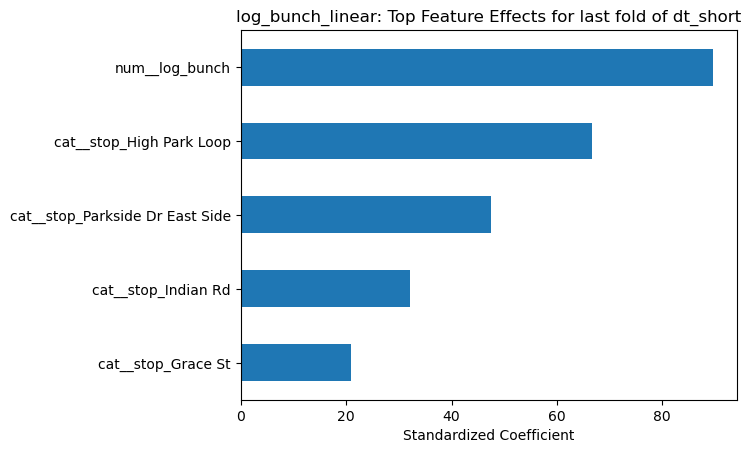

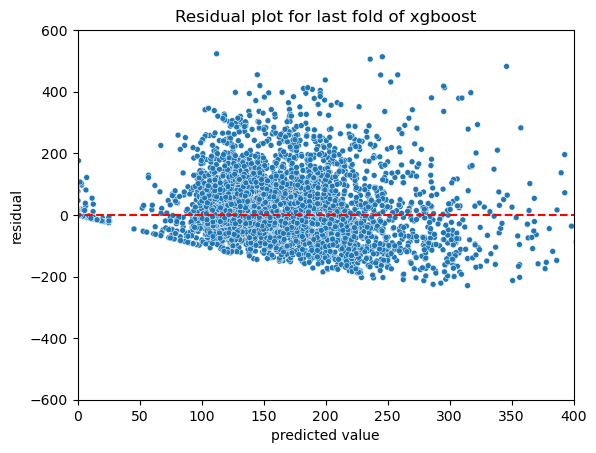

In [18]:
# Store results
rmses = dict()
R2_score = dict()
rmse_means = dict()
R2_means = dict()
rmse_std = dict()
R2_std = dict()

tss = TimeSeriesSplit(n_splits=5)

for model_name, config in models.items():
    num_features = config["num_features"]
    cat_features = config["cat_features"]
    features = num_features + cat_features

    # Scale columns for Linear regression 
    # and one hot encode categorical features for all models
    if config["scale_numeric"]:
        numeric_transformer = StandardScaler()
    else: 
        numeric_transformer = "passthrough"
    

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, num_features),
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_features),
        ],
        remainder="drop"
    )

    
    ## build cv training and testing sets 

    for target_name, target_col in config["target"].items():
        for idx, (tss_train, tss_test) in enumerate(tss.split(daily_df, daily_df.date)):
            df_train = daily_df.iloc[tss_train]
            df_test = daily_df.iloc[tss_test]

            X_train = df_train[features].copy()
            X_test = df_test[features].copy()

            y_train = df_train[target_col].copy()
            y_test = df_test[target_name].copy()

            model_pipe = Pipeline(steps = [
                ("preprocess", preprocessor),
                ("model",clone(config["estimator"]))
                ])
            
            model_pipe.fit(X_train, y_train)
            y_pred = model_pipe.predict(X_test)

            if target_col.startswith("log_"):
                y_pred = np.expm1(y_pred)

            rmses[(model_name, target_name, idx)] = rmse(y_test, y_pred)
            R2_score[(model_name, target_name, idx)] = r2_score(y_test, y_pred)
            
            if idx==4:
                y_resid = y_test - y_pred
                sns.scatterplot(x = y_pred,y = y_resid, size=5, legend=False)
                sns.lineplot(x=[y_pred.min(), y_pred.max()], y=[0,0], color='red', linestyle='--')
                plt.xlabel('predicted value')
                plt.ylabel('residual')
                plt.ylim(-600,600)
                plt.xlim(0,400)
                plt.title(f'Residual plot for last fold of {model_name}')
                plt.show()

                if config["scale_numeric"]:
                    coefs = pd.Series(model_pipe.named_steps["model"].coef_, 
                          index=model_pipe.named_steps["preprocess"].get_feature_names_out())
                    coefs_sorted = coefs.reindex(coefs.abs().sort_values(ascending=False).index)
                    plt.figure()
                    coefs_sorted.head(5).plot(kind='barh')
                    plt.title(f"{model_name}: Top Feature Effects for last fold of {target_col}")
                    plt.xlabel("Standardized Coefficient")
                    plt.gca().invert_yaxis()
                    plt.show()


    rmse_vals = np.array([
            val for key, val in rmses.items()
            if key[0] == model_name and key[1] == target_name
        ])

    rmse_means[(model_name, target_name)] = rmse_vals.mean()
    rmse_std[(model_name, target_name)] = rmse_vals.std()


    R2_vals = np.array([
            val for key, val in R2_score.items()
            if key[0] == model_name and key[1] == target_name
        ])

    R2_means[(model_name, target_name)] = R2_vals.mean()
    R2_std[(model_name, target_name)] = R2_vals.std()



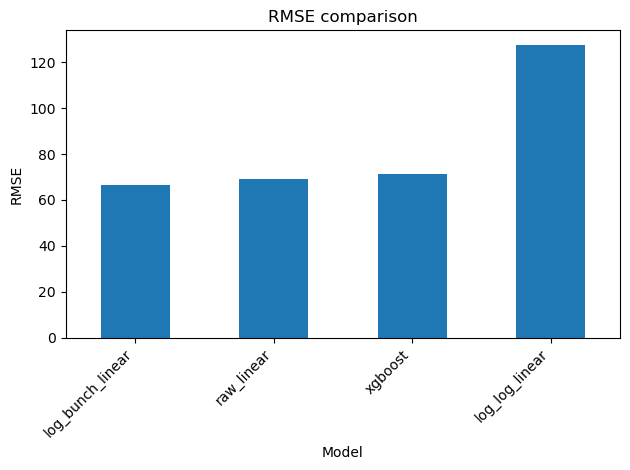

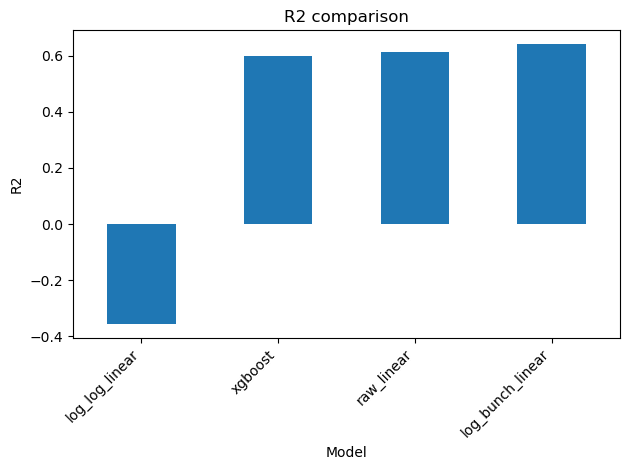

In [19]:
## Plot summary stats from rmse_means and rmse_std

summary = []
for (model, target), avg in rmse_means.items():
        summary.append({
            "model": model,
            "base_model": model,
            "version": "raw",
            "rmse_mean": avg,
            "r2_mean": R2_means[(model, target)]
        })

summary_df = pd.DataFrame(summary)

# rmse 
df_rmse = summary_df.sort_values("rmse_mean", ascending=True)
df_rmse.plot(x="model", y="rmse_mean", kind="bar", legend=False)
plt.title(f"RMSE comparison")
plt.ylabel("RMSE")
plt.xlabel("Model")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# r2 
df_r2 = summary_df.sort_values("r2_mean", ascending=True)
df_r2.plot(x="model", y="r2_mean", kind="bar", legend=False)
plt.title(f"R2 comparison")
plt.ylabel("R2")
plt.xlabel("Model")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


Next we try adding in regularization.

In [20]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import RandomizedSearchCV

## Next we do the parameter tuning 
param_results = []
best_params = dict()

outer_cv = TimeSeriesSplit(n_splits=3, test_size=30)
inner_cv = TimeSeriesSplit(n_splits=2)

for model_name, config in models.items():
    num_features = config["num_features"]
    cat_features = config["cat_features"]
    features = num_features + cat_features

    if config["scale_numeric"]:
        numeric_transformer = StandardScaler()
    else: 
        numeric_transformer = "passthrough"
    
    preprocessor = ColumnTransformer(
        transformers=[
            ("std_scale", numeric_transformer, num_features),
            ("one_hot_encode", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_features)
        ],
        remainder="drop"
    )

    for target_name, target_col in config["target"].items():

        for idx, (out_tss_train, out_tss_test) in enumerate(outer_cv.split(daily_df, daily_df.date)):
            df_train = daily_df.iloc[out_tss_train]
            df_test = daily_df.iloc[out_tss_test]

            X_train = df_train[features].copy()
            X_test = df_test[features].copy()

            y_train = df_train[target_col].copy()
            y_test = df_test[target_name].copy()

## First Ridge and Lasso:
            if model_name != "xgboost":
                if ("ridge_tuned", model_name, target_name) not in best_params:
                    best_params[("ridge_tuned", model_name, target_name)] = []
                if ("lasso_tuned", model_name, target_name) not in best_params:
                    best_params[("lasso_tuned", model_name, target_name)] = []

                
                ridge_pipe = Pipeline(steps=[
                    ("preprocess", preprocessor),
                    ("model", Ridge())
                ])

                lasso_pipe = Pipeline(steps=[
                    ("preprocess", preprocessor),
                    ("model", Lasso(max_iter=10000))
                ])

                ridge_grid = {
                "model__alpha": [0.01, 0.1, 1, 10, 100]
                }

                lasso_grid = {
                "model__alpha": [0.001, 0.01, 0.1, 1]
                }

                ridge_search = GridSearchCV(
                estimator=ridge_pipe,
                param_grid=ridge_grid,
                scoring="neg_root_mean_squared_error",
                cv=inner_cv,
                n_jobs=-1
                )
        
                ridge_search.fit(X_train, y_train)
                y_pred_ridge = ridge_search.best_estimator_.predict(X_test)

                if target_col.startswith("log_"):
                    y_pred_ridge = np.expm1(y_pred_ridge)
           
                ridge_rmse = rmse(y_test, y_pred_ridge)
                ridge_r2 = r2_score(y_test, y_pred_ridge)

                param_results.append({
                "regularization": "ridge_tuned",
                "model": model_name,
                "target": target_name,
                "fold": idx,
                "rmse": ridge_rmse,
                "r2": ridge_r2
                })

                best_params[("ridge_tuned", model_name, target_name)].append(ridge_search.best_params_)


                ## Lasso 

                lasso_search = GridSearchCV(
                estimator=lasso_pipe,
                param_grid=lasso_grid,
                scoring="neg_root_mean_squared_error",
                cv=inner_cv,
                n_jobs=-1
                )
            
                lasso_search.fit(X_train, y_train)
                y_pred_lasso = lasso_search.best_estimator_.predict(X_test)

                if target_col.startswith("log_"):
                    y_pred_lasso = np.expm1(y_pred_lasso)
        
                lasso_rmse = rmse(y_test, y_pred_lasso)
                lasso_r2 = r2_score(y_test, y_pred_lasso)

                param_results.append({
                "regularization": "lasso_tuned",
                "model": model_name,
                "target": target_name,
                "fold": idx,
                "rmse": lasso_rmse,
                "r2": lasso_r2
                })

                best_params[("lasso_tuned", model_name, target_name)].append(lasso_search.best_params_)
                


In [21]:
## XGBoost Seperately
for model_name, config in models.items():
    if model_name == "xgboost":
        num_features = config["num_features"]
        cat_features = config["cat_features"]
        features = num_features + cat_features



        for target_name, target_col in config["target"].items():

            for idx, (out_tss_train, out_tss_test) in enumerate(outer_cv.split(daily_df, daily_df.date)):
                df_train = daily_df.iloc[out_tss_train]
                df_test = daily_df.iloc[out_tss_test]

                X_train = df_train[features].copy()
                X_test = df_test[features].copy()

                y_train = df_train[target_col].copy()
                y_test = df_test[target_name].copy()
            
            
                if ("xgboost_tuned", model_name, target_name) not in best_params:
                    best_params[("xgboost_tuned", model_name, target_name)] = []

                xgb_pipe = Pipeline(steps=[
                    ("model", xgb.XGBRegressor(
                        objective="reg:squarederror",
                        learning_rate=0.1,
                        subsample=0.8,
                        random_state=37,
                        enable_categorical=True
                    ))
                ])

                xgb_grid = {
                    "model__n_estimators": [50, 100],
                    "model__max_depth": [5, 10],
                    "model__reg_alpha": [0, 1, 2, 3, 4, 5, 7, 10],
                    "model__reg_lambda": [0, 1, 2, 3, 5, 7, 10]
                }

                xgb_search = RandomizedSearchCV(
                    estimator=xgb_pipe,
                    param_distributions=xgb_grid,
                    n_iter=10,
                    cv=inner_cv,
                    n_jobs=-1,
                    scoring="neg_root_mean_squared_error",
                    random_state=37
                )

                xgb_search.fit(X_train, y_train)
                y_pred_xgb = xgb_search.best_estimator_.predict(X_test)

            
                xgb_rmse = rmse(y_test, y_pred_xgb)
                xgb_r2 = r2_score(y_test, y_pred_xgb)

                param_results.append({
                    "regularization": "xgboost_tuned",
                    "model": model_name,
                    "target": target_name,
                    "fold": idx,
                    "rmse": xgb_rmse,
                    "r2": xgb_r2
                })

                best_params[("xgboost_tuned", model_name, target_name)].append(xgb_search.best_params_)

In [22]:
best_params_df = pd.DataFrame(best_params)
best_params_df

,ridge_tuned,lasso_tuned,ridge_tuned,lasso_tuned,ridge_tuned,lasso_tuned,xgboost_tuned
,raw_linear,raw_linear,log_log_linear,log_log_linear,log_bunch_linear,log_bunch_linear,xgboost
,dt_short,dt_short,dt_short,dt_short,dt_short,dt_short,dt_short
0,{'model__alpha': 10},{'model__alpha': 1},{'model__alpha': 100},{'model__alpha': 0.001},{'model__alpha': 0.01},{'model__alpha': 1},"{'model__reg_lambda': 10, 'model__reg_alpha': ..."
1,{'model__alpha': 100},{'model__alpha': 1},{'model__alpha': 100},{'model__alpha': 0.001},{'model__alpha': 0.01},{'model__alpha': 1},"{'model__reg_lambda': 7, 'model__reg_alpha': 5..."
2,{'model__alpha': 100},{'model__alpha': 1},{'model__alpha': 100},{'model__alpha': 0.001},{'model__alpha': 0.01},{'model__alpha': 1},"{'model__reg_lambda': 2, 'model__reg_alpha': 0..."


In [23]:
final_params = {
    ("ridge_tuned", "raw_linear"): {"model__alpha": 100},
    ("lasso_tuned", "raw_linear"): {"model__alpha": 1},
    ("ridge_tuned", "log_log_linear"): {"model__alpha": 100},
    ("lasso_tuned", "log_log_linear"): {"model__alpha": 0.001},
    ("ridge_tuned", "log_bunch_linear"): {"model__alpha": 0.01},
    ("lasso_tuned", "log_bunch_linear"): {"model__alpha": 1},
    ("xgboost_tuned", "xgboost"): {"model__reg_lambda":1, "model__max_depth": 5 , "model__reg_alpha": 10 ,"model__n_estimators" : 100},
}
## This is getting annoying so I am pulling these values by hand and I will load them into the new models by hand too 

In [24]:
tuned_models = {
    "raw_ridge": {
        "estimator": Ridge(alpha=100),
        "target": {"dt_short": "dt_short"},
        "cat_features": ["dir", "stop"],
        "num_features": [
            "bunch", "avg_temperature", "avg_wind_speed", "avg_visibility",
            "avg_health_index", "rain", "snow_on_ground", "daylight"
        ],
        "scale_numeric": True,
        "tune" : "ridge"
    },

    "raw_lasso": {
        "estimator": Lasso(alpha=1, max_iter=10000),
        "target": {"dt_short": "dt_short"},
        "cat_features": ["dir", "stop"],
        "num_features": [
            "bunch", "avg_temperature", "avg_wind_speed", "avg_visibility",
            "avg_health_index", "rain", "snow_on_ground", "daylight"
        ],
        "scale_numeric": True,
        "tune" : "lasso"
    },

    "log_log_ridge": {
        "estimator": Ridge(alpha=100),
        "target": {"dt_short": "log_dt_short"},
        "cat_features": ["dir", "stop"],
        "num_features": [
            "log_bunch", "avg_temperature", "avg_wind_speed", "avg_visibility",
            "avg_health_index", "rain", "snow_on_ground", "daylight"
        ],
        "scale_numeric": True,
        "tune" : "ridge"
    },

    "log_log_lasso": {
        "estimator": Lasso(alpha=0.001, max_iter=10000),
        "target": {"dt_short": "log_dt_short"},
        "cat_features": ["dir", "stop"],
        "num_features": [
            "log_bunch", "avg_temperature", "avg_wind_speed", "avg_visibility",
            "avg_health_index", "rain", "snow_on_ground", "daylight"
        ],
        "scale_numeric": True,
        "tune" : "lasso"
    },

    "log_bunch_ridge": {
        "estimator": Ridge(alpha=0.01),
        "target": {"dt_short": "dt_short"},
        "cat_features": ["dir", "stop"],
        "num_features": [
            "log_bunch", "avg_temperature", "avg_wind_speed", "avg_visibility",
            "avg_health_index", "rain", "snow_on_ground", "daylight"
        ],
        "scale_numeric": True,
        "tune" : "ridge"
    },

    "log_bunch_lasso": {
        "estimator": Lasso(alpha=1, max_iter=10000),
        "target": {"dt_short": "dt_short"},
        "cat_features": ["dir", "stop"],
        "num_features": [
            "log_bunch", "avg_temperature", "avg_wind_speed", "avg_visibility",
            "avg_health_index", "rain", "snow_on_ground", "daylight"
        ],
        "scale_numeric": True,
        "tune" : "lasso"
    },

    "xgboost_tuned": {
        "estimator": xgb.XGBRegressor(
            objective="reg:squarederror",
            learning_rate=0.1,
            subsample=0.7,
            max_depth=5,
            reg_alpha=10,
            reg_lambda=1,
            n_estimators=100,
            random_state=37
        ),
        "target": {"dt_short": "dt_short"},
        "cat_features": ["dir", "stop"],
        "num_features": [
            "bunch", "avg_temperature", "avg_wind_speed", "avg_visibility",
            "avg_health_index", "rain", "snow_on_ground", "daylight"
        ],
        "scale_numeric": False,
        "tune" : "tune"
    },
}

Again, the residuals for the log-log model is not appropriate.

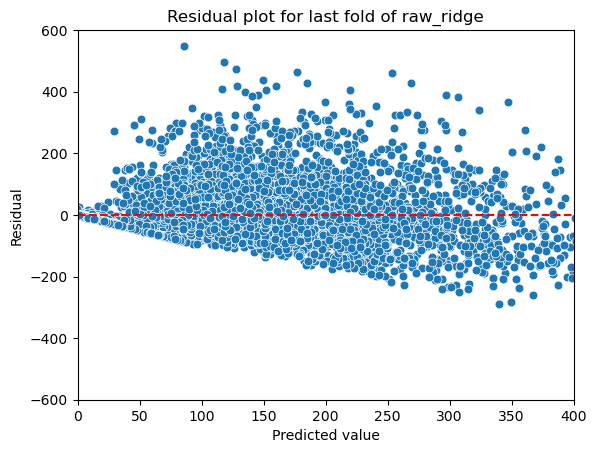

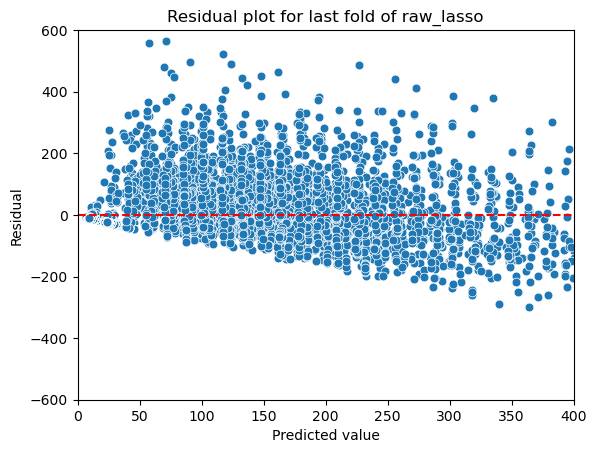

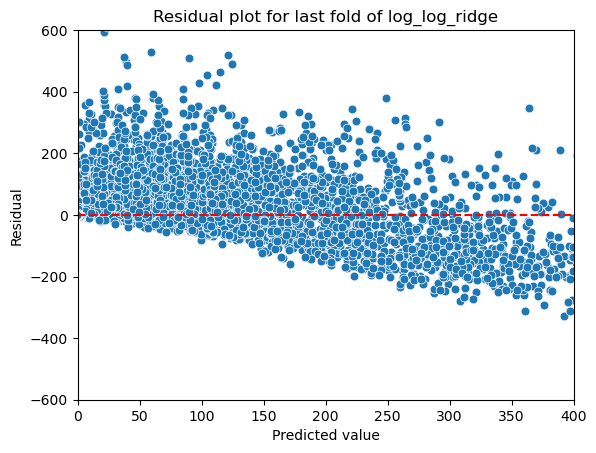

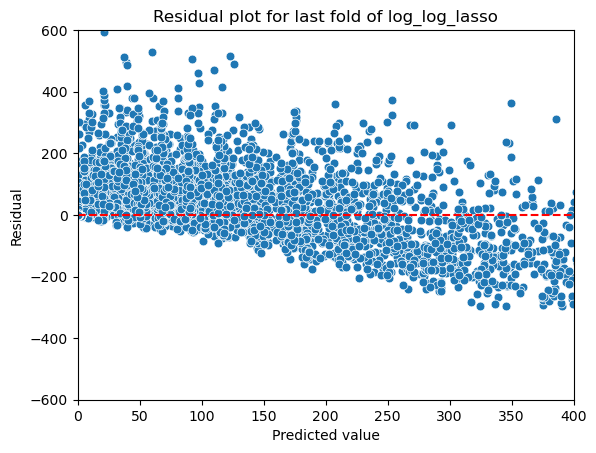

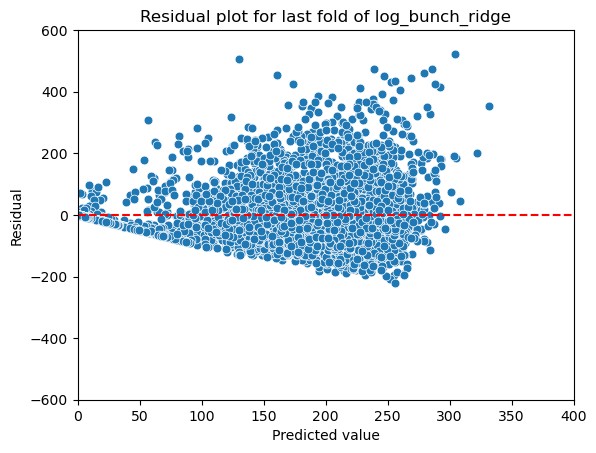

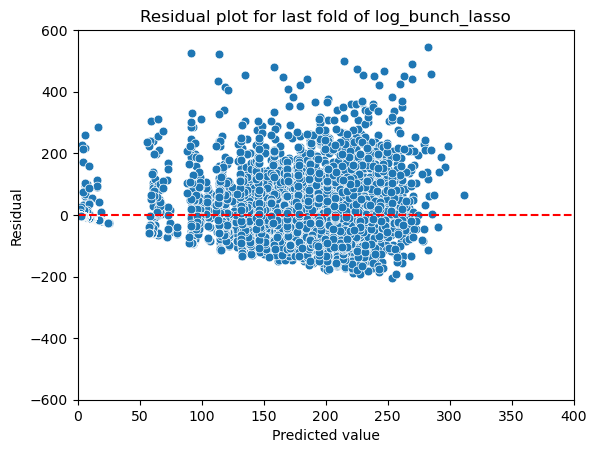

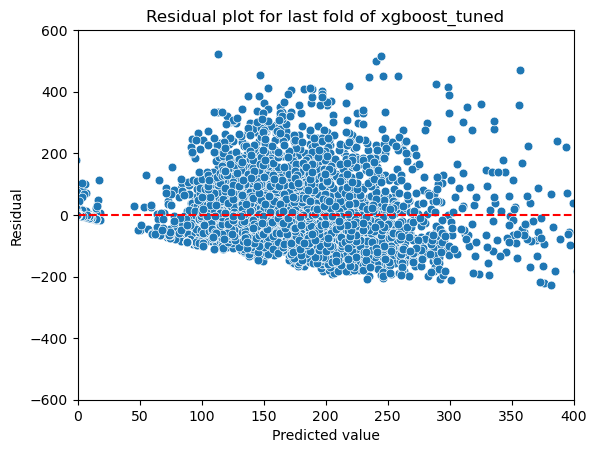

In [25]:

# Store results
tune_rmse = dict()
tune_R2_score = dict()
tune_rmse_means = dict()
tune_R2_means = dict()
tune_rmse_std = dict()
tune_R2_std = dict()

tss = TimeSeriesSplit(n_splits=5)

for model_name, config in tuned_models.items():
    num_features = config["num_features"]
    cat_features = config["cat_features"]
    features = num_features + cat_features

    if config["scale_numeric"]:
        numeric_transformer = StandardScaler()
    else:
        numeric_transformer = "passthrough"

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, num_features),
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_features),
        ],
        remainder="drop"
    )

    # build cv training and testing sets
    for target_name, target_col in config["target"].items():
        for idx, (tss_train, tss_test) in enumerate(tss.split(daily_df, daily_df.date)):
            df_train = daily_df.iloc[tss_train]
            df_test = daily_df.iloc[tss_test]

            X_train = df_train[features].copy()
            X_test = df_test[features].copy()

            y_train = df_train[target_col].copy()
            y_test = df_test[target_name].copy()

            model_pipe = Pipeline(steps=[
                ("preprocess", preprocessor),
                ("model", clone(config["estimator"]))
            ])

            model_pipe.fit(X_train, y_train)
            y_pred = model_pipe.predict(X_test)

            if target_col.startswith("log_"):
                y_pred = np.expm1(y_pred)
                
            tune_rmse[(model_name, target_name, idx)] = rmse(y_test, y_pred)
            tune_R2_score[(model_name, target_name, idx)] = r2_score(y_test, y_pred)

            # plots for final fold
            if idx == 4:
                y_resid = y_test - y_pred

                sns.scatterplot(x=y_pred, y=y_resid, s=40, legend=False)
                plt.axhline(0, color="red", linestyle="--")
                plt.xlabel("Predicted value")
                plt.ylabel("Residual")
                plt.ylim(-600, 600)
                plt.xlim(0, 400)
                plt.title(f"Residual plot for last fold of {model_name}")
                plt.show()

                
        # summary stats for this model/target
        rmse_vals = np.array([
            val for key, val in tune_rmse.items()
            if key[0] == model_name and key[1] == target_name
        ])
        tune_rmse_means[(model_name, target_name)] = rmse_vals.mean()
        tune_rmse_std[(model_name, target_name)] = rmse_vals.std()

        R2_vals = np.array([
            val for key, val in tune_R2_score.items()
            if key[0] == model_name and key[1] == target_name
        ])
        tune_R2_means[(model_name, target_name)] = R2_vals.mean()
        tune_R2_std[(model_name, target_name)] = R2_vals.std()

A final plot of our metrics is given below

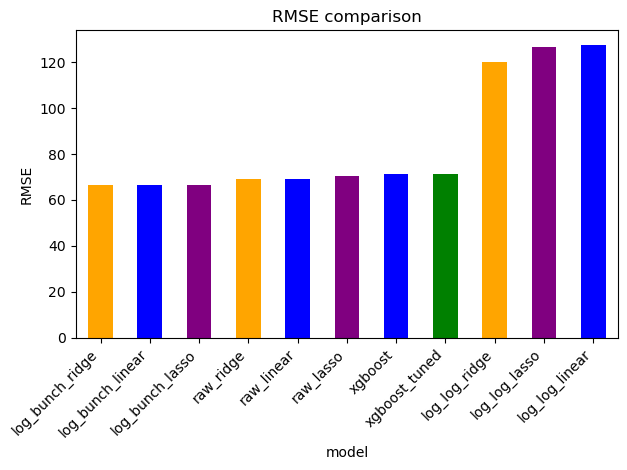

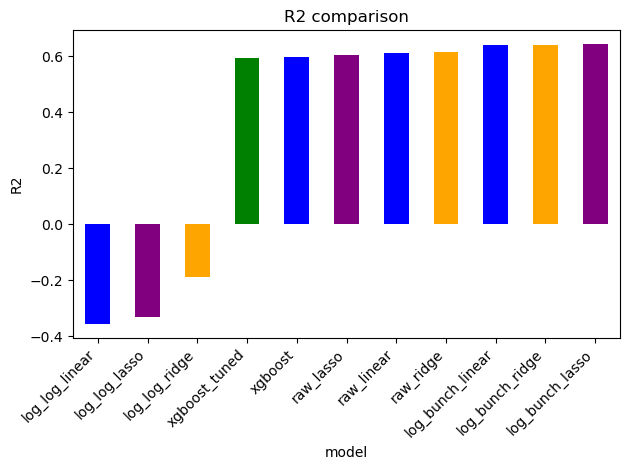

In [26]:
tune_summary = []

# Maps to group the models together 

tuned_base = {
    "raw_ridge": ("raw_linear", "ridge"),
    "raw_lasso": ("raw_linear", "lasso"),
    "log_log_ridge": ("log_log_linear", "ridge"),
    "log_log_lasso": ("log_log_linear", "lasso"),
    "log_bunch_ridge": ("log_bunch_linear", "ridge"),
    "log_bunch_lasso": ("log_bunch_linear", "lasso"),
    "xgboost_tuned": ("xgboost", "xgb_tuned")
}

for (model, target), avg in tune_rmse_means.items():
    if model in tuned_base:
        base_model, version = tuned_base[model]
        tune_summary.append({
            "model": model,
            "base_model": base_model,
            "version": version,
            "rmse_mean": avg,
            "r2_mean": tune_R2_means[(model, target)]
        })

tune_summary_df = pd.DataFrame(tune_summary)


## Merge the two together
comparison_df = pd.concat([summary_df, tune_summary_df], ignore_index=True)
comparison_df = comparison_df.sort_values(["base_model", "version"])
comparison_df

colors = {"raw": "blue", "ridge": "orange", "lasso": "purple", "xgb_tuned": "green"}

comparison_df["color"] = comparison_df["version"].map(colors)

df_plot = comparison_df.sort_values(["base_model", "version"])
df_rmse = df_plot.sort_values("rmse_mean")

df_rmse.plot(
    x="model",
    y="rmse_mean",
    kind="bar",
    color=df_rmse["color"],
    legend=False
)

plt.title("RMSE comparison")
plt.ylabel("RMSE")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

df_r2 = df_plot.sort_values("r2_mean")

df_r2.plot(
    x="model",
    y="r2_mean",
    kind="bar",
    color=df_r2["color"],
    legend=False
)

plt.title("R2 comparison")
plt.ylabel("R2")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [27]:
comparison_df.sort_values("rmse_mean")

,model,base_model,version,rmse_mean,r2_mean,color
8,log_bunch_ridge,log_bunch_linear,ridge,66.711752,0.640193,orange
2,log_bunch_linear,log_bunch_linear,raw,66.711768,0.640192,blue
9,log_bunch_lasso,log_bunch_linear,lasso,66.724282,0.642493,purple
4,raw_ridge,raw_linear,ridge,69.192398,0.613262,orange
0,raw_linear,raw_linear,raw,69.213783,0.612423,blue
5,raw_lasso,raw_linear,lasso,70.291277,0.603501,purple
3,xgboost,xgboost,raw,71.139423,0.598175,blue
10,xgboost_tuned,xgboost,xgb_tuned,71.444845,0.593991,green
6,log_log_ridge,log_log_linear,ridge,120.289048,-0.189349,orange
7,log_log_lasso,log_log_linear,lasso,126.599168,-0.330887,purple


Most linear models perform pretty similarly in $R^2$-score and regularization did not produce significantly better results in the test.